# Download and mask ERA5 data for Africa

This notebook downloads monthly ERA5 temperature data from the Copernicus Climate Data Store using `cdsapi`, extracts the NetCDF file, applies a precise Africa mask using `c3s_atlas.mask_africa`, previews the result, and saves the final masked NetCDF.

Before running it, make sure your CDS credentials are configured in `~/.cdsapirc`.

In [14]:
from importlib import reload
from pathlib import Path

import cdsapi
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import regionmask
from shapely.ops import unary_union

import c3s_atlas.customized_regions as cr
from c3s_atlas.utils import extract_zip_and_delete


## Resolve project paths

This makes the notebook work whether Jupyter was started from the repository root or from a subdirectory.

In [15]:
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "auxiliar").exists()
)

dest = repo_root / "book" / "customizing" / "data" / "africa_era5"
dest.mkdir(parents=True, exist_ok=True)

repo_root, dest


(PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main'),
 PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5'))

## Download ERA5 from CDS

The request uses the `multi-origin-c3s-atlas` dataset already used in this repository. The geographical subset is a broad Africa bounding box, and the precise continent mask is applied afterward.

In [16]:
c = cdsapi.Client()

zip_path = dest / "t_ERA5_Africa.zip"
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "era5",
    "domain": "global",
    "period": "1940-2024",
    "variable": "monthly_temperature",
    "bias_adjustment": "no_bias_adjustment",
    "area": [38, -20, -36, 55],
}

if not list(dest.glob("*.nc")):
    c.retrieve(dataset, request).download(zip_path)
    extract_zip_and_delete(zip_path)
    print("Download and extraction complete.")
else:
    print(f"NetCDF already present in {dest}")


NetCDF already present in /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5


## Open the downloaded NetCDF

In [17]:
nc_files = sorted(
    path for path in dest.glob("*.nc")
    if path.name != "era5_africa_masked.nc"
)
if not nc_files:
    raise FileNotFoundError(f"No NetCDF file found in {dest}")

nc_path = nc_files[0]
ds = xr.open_dataset(nc_path)

print("Opened:", nc_path.name)
print("Dimensions:", ds.dims)
print("Data variables:", list(ds.data_vars))
ds


Opened: t_ERA5_Africa.nc
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 297, 'bnds': 2, 'lon': 301, 'time': 1020})
Data variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 't', 'crs']


<xarray.Dataset> Size: 365MB
Dimensions:    (lat: 297, bnds: 2, lon: 301, time: 1020)
Coordinates:
  * lat        (lat) float64 2kB -36.0 -35.75 -35.5 -35.25 ... 37.5 37.75 38.0
  * lon        (lon) float64 2kB -20.0 -19.75 -19.5 -19.25 ... 54.5 54.75 55.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
    height2m   float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    time_bnds  (time, bnds) datetime64[ns] 16kB ...
    t          (time, lat, lon) float32 365MB ...
    crs        int32 4B ...
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-26 16:45:54.743007+01:00
    tracking_id:                b868b9c8-72fb-42b6-a397-eee5cd0c62f1
    project_id:                 c3s-cica-atlas

## Build a precise Africa mask from Natural Earth and apply it

This avoids the incomplete local Africa GeoJSON and uses the Natural Earth country boundaries directly.

In [18]:
reload(cr)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
africa_gdf = world[world["CONTINENT"] == "Africa"].copy()

# Fix possible geometry issues before dissolving into one continent polygon.
africa_gdf["geometry"] = africa_gdf.geometry.buffer(0)
africa_shape = unary_union(africa_gdf.geometry)

africa_region = regionmask.Regions(
    [africa_shape],
    names=["Africa"],
    abbrevs=["AFR"],
    name="Africa continent",
)

mask = africa_region.mask(ds["lon"], ds["lat"])
ds_africa = ds.where(mask == 0)
ds_africa = cr.crop_to_bbox(ds_africa, lon_bounds=(-18.0, 52.0), lat_bounds=(-35.0, 37.5))

print("African entities used:", len(africa_gdf))
print("Sample names:", africa_gdf["NAME"].head().tolist())
print("Masked dimensions:", ds_africa.dims)
print("Masked variables:", list(ds_africa.data_vars))
ds_africa


African entities used: 51
Sample names: ['Tanzania', 'W. Sahara', 'Dem. Rep. Congo', 'Somalia', 'Kenya']
Masked dimensions: FrozenMappingWarningOnValuesAccess({'lat': 291, 'bnds': 2, 'lon': 281, 'time': 1020})
Masked variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 't', 'crs']


<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 291, bnds: 2, lon: 281, time: 1020)
Coordinates:
  * lat        (lat) float64 2kB -35.0 -34.75 -34.5 -34.25 ... 37.0 37.25 37.5
  * lon        (lon) float64 2kB -18.0 -17.75 -17.5 -17.25 ... 51.5 51.75 52.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
    height2m   float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds, lon) float64 1MB nan nan nan nan ... nan nan nan nan
    lon_bnds   (lon, bnds, lat) float64 1MB nan nan nan nan ... nan nan nan nan
    time_bnds  (time, bnds, lat, lon) datetime64[ns] 1GB NaT NaT NaT ... NaT NaT
    t          (time, lat, lon) float32 334MB nan nan nan nan ... nan nan nan
    crs        (lat, lon) float64 654kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-26 16:45:54.743007+01:00
    tracking_id:                b868b9c8-72fb-42b6-a397-eee5cd0c62f1
    project_id:                 c3s-cica-atlas

## Quick preview

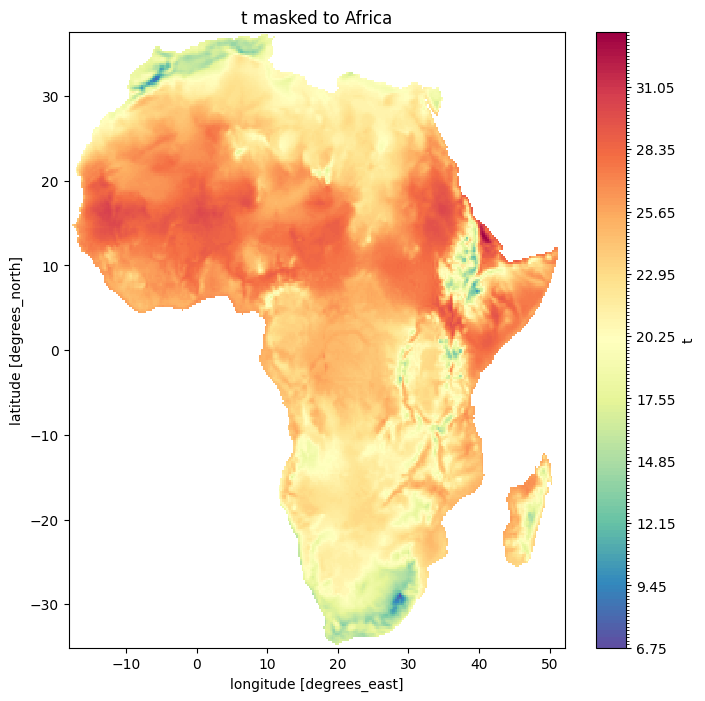

In [29]:
preferred_vars = ["t", "t2m", "tas", "monthly_temperature"]
var_name = next((name for name in preferred_vars if name in ds_africa.data_vars), None)

if var_name is None:
    candidates = [
        name for name, da in ds_africa.data_vars.items()
        if {"lat", "lon"}.issubset(da.dims) and "bnds" not in da.dims
    ]
    if not candidates:
        raise ValueError("No plottable data variable with lat/lon dimensions was found.")
    var_name = candidates[0]

da = ds_africa[var_name]
time_dims = [dim for dim in ("time", "valid_time") if dim in da.dims]
plot_da = da.mean(time_dims[0], skipna=True) if time_dims else da

#plot_da.plot(figsize=(8, 8), cmap="coolwarm", vmin=10, vmax=35)
plot_da.plot(figsize=(8, 8), cmap="Spectral_r", levels=255)


plt.title(f"{var_name} masked to Africa")
plt.show()


## Save the final Africa-only NetCDF

This drops auxiliary bounds variables before writing to keep the output cleaner and lighter.

In [21]:
bounds_vars = [name for name in ds_africa.variables if "bnds" in name.lower() or name.lower().endswith("_bounds")]
ds_africa_clean = ds_africa.drop_vars(bounds_vars, errors="ignore")
output_path = dest / "era5_africa_masked.nc"

if output_path.exists():
    output_path.unlink()

ds.close()
 
output_path = dest / "era5_africa_masked.nc"
encoding = {
    name: {"zlib": True, "complevel": 1}
    for name in ds_africa_clean.data_vars
}

ds_africa_clean.to_netcdf(output_path, encoding=encoding)
print("Saved:", output_path)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5/era5_africa_masked.nc
